In [1]:
import random
import csv
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import List, Tuple



In [2]:
@dataclass
class Restaurant:
    cuisines:list
    price_range:str
    has_self_del:bool
    has_offer:bool
    has_extra_del_cost:bool
    min_cost:float
    avg_rating:float
    avg_del_time:int
    payment_methods:list


In [3]:


def generate_restaurants(
    rest_num: int = 100,
    cuisine_num_max: int = 4,
    cuisine_options: List[str] =  ['Pizza', 'Burger', 'Pasta', 'Souvlaki', 'Sushi', 'Chinese'],
    price_options: List[str] = ["$", "$$", "$$$", "$$$$"],
    price_options_distro: List[float] =  [0.5, 0.3, 0.15, 0.05],
    extra_del_cost_prob: float = 0.2,
    min_cost_gaussian_params: Tuple[float, float] = (6, 3),
    avg_rating_gaussian_params: Tuple[float, float] = (3, 1),
    avg_del_time_gaussian_params: Tuple[float, float] = (30, 15),
    payment_methods: Tuple[str, ...] = ('CASH', 'CARD', 'COUPON')
) -> List[Restaurant]:
    """
    Generates a list of restaurants with randomized attributes.

    Args:
    - rest_num (int): Number of restaurants to generate (default: 100).
    - cuisine_num_max (int): Maximum number of cuisines per restaurant (default: 4).
    - cuisine_options (List[str]): Available cuisines (default: ['Pizza', 'Burger', 'Pasta', 'Souvlaki', 'Sushi', 'Chinese']).
    - price_options (List[str]): Price range options (default: ["$", "$$", "$$$", "$$$$"]).
    - price_options_distro (List[float]): Probability distribution of price options (default: [0.5, 0.3, 0.15, 0.05]).
    - extra_del_cost_prob (float): Probability of extra delivery cost (default: 0.2).
    - min_cost_gaussian_params (Tuple[float, float]): Mean and std deviation for minimum order cost (default: (6,3)).
    - avg_rating_gaussian_params (Tuple[float, float]): Mean and std deviation for average rating (default: (3,1)).
    - avg_del_time_gaussian_params (Tuple[float, float]): Mean and std deviation for average delivery time (default: (30,15)).
    - payment_methods (Tuple[str, ...]): Available payment methods (default: ('CASH', 'CARD', 'COUPON')).

    Returns:
    - List[Restaurant]: A list of generated restaurant objects.
    """


    restaurants = []

    for _ in range(rest_num):
        # Pick a random number of cuisines
        cuisine_num = random.randint(1, cuisine_num_max)
        cuisines = random.sample(cuisine_options, cuisine_num)

        # Sample price range based on probability distribution
        price_index = np.random.choice(len(price_options), p=price_options_distro)
        price_range = price_options[price_index]

        # Random attributes
        has_self_del = random.choice([True, False])
        has_offer = random.choice([True, False])
        has_extra_del_cost = random.random() < extra_del_cost_prob

        # Sample Gaussian-distributed values (ensuring non-negative)
        min_cost = round(max(0, random.gauss(*min_cost_gaussian_params)), 1)
        avg_rating = round(max(0, random.gauss(*avg_rating_gaussian_params)), 1)
        avg_del_time = round(max(0, random.gauss(*avg_del_time_gaussian_params)), 1)

        # Sample payment methods
        selected_payment_methods = random.sample(payment_methods, random.randint(1, len(payment_methods)))

        # Create restaurant object
        restaurants.append(
            Restaurant(
                cuisines=cuisines,
                price_range=price_range,
                has_self_del=has_self_del,
                has_offer=has_offer,
                has_extra_del_cost=has_extra_del_cost,
                min_cost=min_cost,
                avg_rating=avg_rating,
                avg_del_time=avg_del_time,
                payment_methods=selected_payment_methods
            )
        )

    return restaurants


In [4]:
restaurants=generate_restaurants(rest_num=100)

In [5]:
restaurants[7]

Restaurant(cuisines=['Sushi', 'Burger'], price_range='$$', has_self_del=False, has_offer=False, has_extra_del_cost=False, min_cost=3.5, avg_rating=3.2, avg_del_time=9.0, payment_methods=['CASH', 'COUPON'])

In [6]:
restaurants[2].avg_del_time

35.4

In [7]:
@dataclass
class User:
    gender:str
    age:int
    favorite_cuisines:list


In [8]:


def generate_users_segment1(user_num: int = 1000) -> List[User]:
    """
    Generates a list of users for Segment 1: One-Trick Pony.

    Characteristics:
    - 50% Male, 50% Female (randomly assigned)
    - Single favorite cuisine
    - Age follows a Gaussian distribution with a mean of 60 and std deviation of 7

    Args:
    - user_num (int): Number of users to generate (default: 1000)

    Returns:
    - List[User]: A list of generated users.
    """

    available_cuisines = ['Pizza', 'Burger', 'Pasta', 'Souvlaki', 'Sushi', 'Chinese']

    users = [
        User(
            gender=random.choice(["M", "F"]),
            age=max(0, int(random.gauss(60, 7))),  # Ensure non-negative age
            favorite_cuisines=random.sample(available_cuisines, 1)  # Single favorite cuisine
        )
        for _ in range(user_num)
    ]

    return users


In [9]:

import csv
import random
from typing import List

def generate_ratings_segment1(users: List[User], restaurants: List[Restaurant], output_file: str = 'segment1.csv') -> None:
    """
    Generates ratings for Segment 1: One-Trick Pony.

    Criteria:
    - AVG_RATING > 4
    - AVG_DEL_TIME <= 35 min
    - HAS_OFFER: 60% influence on rating
    - 90% consistent rating behavior

    Args:
    - users (List[User]): List of user objects.
    - restaurants (List[Restaurant]): List of restaurant objects.
    - output_file (str): Name of the CSV file to save ratings (default: 'segment1.csv').

    Returns:
    - None (Writes data to CSV file).
    """

    with open(output_file, 'w', newline='') as fw:
        writer = csv.writer(fw)
        writer.writerow([
            'age', 'gender', 'favorite_cuisines', 'restaurant_cuisines', 'price_range',
            'has_self_del', 'has_offer', 'has_extra_del_cost', 'min_cost',
            'avg_rating', 'avg_del_time', 'payment_methods', 'rating', 'reason'
        ])

        positive_ratings = 0
        total_ratings = 0

        for user in users:
            rating_count = random.randint(1, len(restaurants))
            total_ratings += rating_count
            sampled_restaurants = random.sample(restaurants, rating_count)

            for restaurant in sampled_restaurants:
                rating = -1  # Default: negative rating
                reason = ""

                # Check if the restaurant matches user's single favorite cuisine and meets criteria
                if user.favorite_cuisines[0] in restaurant.cuisines:
                    if restaurant.avg_rating > 4 and restaurant.avg_del_time <= 35:
                        # 50-50 chance or boosted by HAS_OFFER (60% probability)
                        if random.random() < 0.5 or (restaurant.has_offer and random.random() <= 0.6):
                            rating = 1
                            positive_ratings += 1
                            reason = "Good rating & fast delivery"
                            if restaurant.has_offer:
                                reason += " + Offer available"
                        else:
                            reason = "Did not meet offer or random condition"
                    else:
                        reason = "Rating too low or delivery too slow"
                else:
                    reason = "Not preferred cuisine"

                # 90% consistency: 10% chance of flipping rating
                if random.random() < 0.1:
                    rating *= -1
                    reason += " Rating was flipped due to insconsistnet behavior"

                writer.writerow([
                    user.age, user.gender, user.favorite_cuisines, restaurant.cuisines, restaurant.price_range,
                    restaurant.has_self_del, restaurant.has_offer, restaurant.has_extra_del_cost,
                    restaurant.min_cost, restaurant.avg_rating, restaurant.avg_del_time,
                    restaurant.payment_methods, rating, reason
                ])

    print(f'Positive Ratings: {positive_ratings / total_ratings:.2%}')


In [10]:
users_segment1=generate_users_segment1(user_num=1000)
generate_ratings_segment1(users_segment1,restaurants)

Positive Ratings: 1.80%


In [11]:


def generate_users_segment2(user_num: int = 1000, postcode_num: int = 50) -> List[User]:
    """
    Generates a list of users for Segment 2: young and price-driven.

    Characteristics:
    - 50% Male, 50% Female (randomly assigned)
    - Multiple favorite cuisines (at least 2)
    - Age follows a Gaussian distribution with a mean of 20 and std deviation of 7

    Args:
    - user_num (int): Number of users to generate (default: 1000)
    - postcode_num (int): Number of postcodes to generate (not used in function) (default: 50)

    Returns:
    - List[User]: A list of generated users.
    """

    available_cuisines = ['Pizza', 'Burger', 'Pasta', 'Souvlaki', 'Sushi', 'Chinese']

    users = [
        User(
            gender=random.choice(["M", "F"]),
            age=max(0, int(random.gauss(20, 7))),  # Ensure non-negative age
            favorite_cuisines=random.sample(available_cuisines, random.randint(2, 6))
        )
        for _ in range(user_num)
    ]

    return users


In [12]:

def generate_ratings_segment2(users: List[User], restaurants: List[Restaurant], output_file: str = 'segment2.csv') -> None:
    """
    Generates ratings for Segment 2: young and price-driven.

    Criteria:
    - AVG_RATING > 4.2 if price is $$$
    - AVG_RATING > 3.5 if price is $$
    - AVG_RATING > 3 if price is $
    - No ratings if price is $$$$
    - No ratings if restaurant has an extra delivery cost
    - HAS_OFFER boosts rating probability: 80% influence for $$$, 60% influence for $, $$
    - 80% consistency in rating behavior

    Args:
    - users (List[User]): List of user objects.
    - restaurants (List[Restaurant]): List of restaurant objects.
    - output_file (str): Name of the CSV file to save ratings (default: 'segment2.csv').
    """

    with open(output_file, 'w', newline='') as fw:
        writer = csv.writer(fw)
        writer.writerow([
            'age', 'gender', 'favorite_cuisines', 'restaurant_cuisines', 'price_range',
            'has_self_del', 'has_offer', 'has_extra_del_cost', 'min_cost',
            'avg_rating', 'avg_del_time', 'payment_methods', 'rating', 'reason'
        ])

        positive_ratings = 0
        total_ratings = 0

        for user in users:
            num_ratings = random.randint(1, len(restaurants))
            total_ratings += num_ratings
            sampled_restaurants = random.sample(restaurants, num_ratings)

            for restaurant in sampled_restaurants:
                rating = -1  # Default negative rating
                reason = ""

                if any(cuisine in restaurant.cuisines for cuisine in user.favorite_cuisines):
                    if restaurant.has_extra_del_cost:
                        reason = "Extra delivery cost"
                    else:
                        if (
                            (restaurant.price_range == '$' and restaurant.avg_rating > 3) or
                            (restaurant.price_range == '$$' and restaurant.avg_rating > 3.5) or
                            (restaurant.price_range == '$$$' and restaurant.avg_rating > 4.2)
                        ):
                            # Rating decision logic with offer influence
                            if (
                                random.random() < 0.5 or
                                (restaurant.has_offer and restaurant.price_range in ['$', '$$'] and random.random() <= 0.6) or
                                (restaurant.has_offer and restaurant.price_range == '$$$' and random.random() <= 0.8)
                            ):
                                rating = 1
                                positive_ratings += 1
                                reason = "Good price-quality balance"
                                if restaurant.has_offer:
                                    reason += " + Offer available"
                            else:
                                reason = "Did not meet offer or price conditions"
                        else:
                            reason = "Did not meet rating and price conditions"
                else:
                    reason = "Not preferred cuisine"

                # 80% consistency factor (flip rating 20% of the time)
                if random.random() < 0.2:
                    rating *= -1
                    reason += " Inconsistent rating behavior"


                writer.writerow([
                    user.age, user.gender, user.favorite_cuisines, restaurant.cuisines, restaurant.price_range,
                    restaurant.has_self_del, restaurant.has_offer, restaurant.has_extra_del_cost,
                    restaurant.min_cost, restaurant.avg_rating, restaurant.avg_del_time,
                    restaurant.payment_methods, rating, reason
                ])

    print(f'Positive Ratings: {positive_ratings/total_ratings:.2%} ({positive_ratings}/{total_ratings})')



In [13]:
users_segment2=generate_users_segment2(user_num=2000)
generate_ratings_segment2(users_segment2,restaurants)


Positive Ratings: 10.01% (10368/103541)


In [14]:
file_paths = ['segment1.csv', 'segment2.csv']  # Add as many paths as needed

# Read each CSV file into a DataFrame and store them in a list
dfs = [pd.read_csv(file_path) for file_path in file_paths]

# Concatenate all DataFrames into a single DataFrame
combined_df = pd.concat(dfs, ignore_index=True)

# Shuffle the rows of the combined DataFrame
df = combined_df.sample(frac=1).reset_index(drop=True)

# shuffled_df now contains all your data, shuffled
print(df.shape)

(154209, 14)


In [15]:
df

,age,gender,favorite_cuisines,restaurant_cuisines,price_range,has_self_del,has_offer,has_extra_del_cost,min_cost,avg_rating,avg_del_time,payment_methods,rating,reason
0,18,M,"['Burger', 'Pasta', 'Chinese', 'Souvlaki']","['Sushi', 'Burger', 'Souvlaki', 'Pasta']",$,True,False,False,7.5,3.8,46.4,"['CASH', 'CARD']",1,Did not meet offer or price conditions Inconsi...
1,69,M,['Burger'],"['Souvlaki', 'Chinese', 'Sushi', 'Pasta']",$,False,False,True,8.7,1.8,21.5,"['CARD', 'CASH']",-1,Not preferred cuisine
2,62,M,['Sushi'],['Burger'],$,True,False,False,8.6,1.0,22.8,['COUPON'],-1,Not preferred cuisine
3,54,M,['Burger'],['Burger'],$$$,True,True,True,7.4,2.9,47.7,"['CASH', 'COUPON']",-1,Rating too low or delivery too slow
4,70,M,['Souvlaki'],['Chinese'],$$$,False,True,True,9.7,2.2,34.9,"['CARD', 'COUPON']",-1,Not preferred cuisine
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154204,28,F,"['Pasta', 'Burger', 'Souvlaki', 'Sushi']",['Sushi'],$,False,True,False,2.1,3.3,52.6,"['COUPON', 'CASH']",1,Good price-quality balance + Offer available
154205,14,F,"['Burger', 'Pasta', 'Pizza']","['Souvlaki', 'Pizza', 'Chinese']",$$,True,False,False,5.2,4.3,54.1,"['COUPON', 'CASH']",1,Good price-quality balance
154206,17,M,"['Chinese', 'Souvlaki', 'Pizza', 'Sushi']",['Chinese'],$$$,False,True,False,0.8,2.6,3.8,['CASH'],1,Did not meet rating and price conditions Incon...
154207,14,F,"['Burger', 'Pasta', 'Souvlaki', 'Sushi']",['Chinese'],$,False,False,False,7.0,2.7,0.0,['CASH'],1,Not preferred cuisine Inconsistent rating beha...


In [16]:
def random_recommender(user: User, restaurants: List[Restaurant], top_n: int = 5) -> List[Restaurant]:
    # Randomly sample top_n restaurants from the full list (no replacement)
    recommended = random.sample(restaurants, top_n)

    return recommended


In [17]:
def simulate_random_recommender(users: List[User], restaurants: List[Restaurant], top_n: int = 5) -> None:
    """
    For each user, recommend top_n random restaurants and show
    whether the user liked each one or not, with a reason why.
    At the end, prints the overall hit rate.
    """

    total_shown = 0
    total_liked = 0
    rows = []

    for i, user in enumerate(users):
        # Get random recommendations for this user
        recs = random_recommender(user, restaurants, top_n=top_n)

        for r in recs:
            total_shown += 1
            liked = False
            reason = ""

            # --- Segment 1 logic: single favorite cuisine ---
            if len(user.favorite_cuisines) == 1:
                if user.favorite_cuisines[0] not in r.cuisines:
                    reason = "Wrong cuisine"
                elif r.avg_rating <= 4:
                    reason = "Rating too low"
                elif r.avg_del_time > 35:
                    reason = "Delivery too slow"
                else:
                    liked = True
                    reason = "Cuisine match + good rating + fast delivery"

            # --- Segment 2 logic: multiple cuisines, price-sensitive ---
            else:
                if not any(c in r.cuisines for c in user.favorite_cuisines):
                    reason = "Wrong cuisine"
                elif r.has_extra_del_cost:
                    reason = "Extra delivery cost"
                elif r.price_range == '$$$$':
                    reason = "Too expensive"
                elif not (
                    (r.price_range == '$'   and r.avg_rating > 3)   or
                    (r.price_range == '$$'  and r.avg_rating > 3.5) or
                    (r.price_range == '$$$' and r.avg_rating > 4.2)
                ):
                    reason = "Price/rating threshold not met"
                else:
                    liked = True
                    reason = "Cuisine match + good price/rating"

            if liked:
                total_liked += 1

            rows.append({
                'User #':       i + 1,
                'Age':          user.age,
                'Gender':       user.gender,
                'Fav Cuisines': user.favorite_cuisines,
                'Rest Cuisines':r.cuisines,
                'Price':        r.price_range,
                'Avg Rating':   r.avg_rating,
                'Del Time':     r.avg_del_time,
                'Has Offer':    r.has_offer,
                'Liked':        '+' if liked else '-',
                'Reason':       reason
            })

    # Show as a DataFrame — easy to read
    results_df = pd.DataFrame(rows)
    display(results_df)

    # Summary at the bottom
    hit_rate = total_liked / total_shown
    print(f"\nTotal Shown: {total_shown} | Liked: {total_liked} | Hit Rate: {hit_rate:.2%}")


In [18]:
print("=== Segment 1 (One-Trick Pony) ===")
simulate_random_recommender(random.sample(users_segment1, 5), restaurants, top_n=5)

print()

print("=== Segment 2 (Young & Price-Driven) ===")
simulate_random_recommender(random.sample(users_segment2, 5), restaurants, top_n=5)


=== Segment 1 (One-Trick Pony) ===


,User #,Age,Gender,Fav Cuisines,Rest Cuisines,Price,Avg Rating,Del Time,Has Offer,Liked,Reason
0,1,62,M,[Burger],"[Burger, Sushi, Souvlaki]",$,4.2,10.5,True,+,Cuisine match + good rating + fast delivery
1,1,62,M,[Burger],[Burger],$,2.4,5.5,False,-,Rating too low
2,1,62,M,[Burger],[Sushi],$$$,1.6,20.8,True,-,Wrong cuisine
3,1,62,M,[Burger],"[Chinese, Pasta, Souvlaki, Burger]",$$,2.8,24.9,False,-,Rating too low
4,1,62,M,[Burger],[Sushi],$$$,3.0,47.5,False,-,Wrong cuisine
5,2,60,M,[Sushi],"[Pizza, Burger, Chinese, Pasta]",$$$$,2.7,16.9,False,-,Wrong cuisine
6,2,60,M,[Sushi],"[Burger, Souvlaki, Pasta]",$$,2.5,23.5,True,-,Wrong cuisine
7,2,60,M,[Sushi],"[Sushi, Pasta, Pizza]",$$$,4.2,19.0,False,+,Cuisine match + good rating + fast delivery
8,2,60,M,[Sushi],[Sushi],$$$,1.6,20.8,True,-,Rating too low
9,2,60,M,[Sushi],[Burger],$$,4.8,26.6,False,-,Wrong cuisine



Total Shown: 25 | Liked: 3 | Hit Rate: 12.00%

=== Segment 2 (Young & Price-Driven) ===


,User #,Age,Gender,Fav Cuisines,Rest Cuisines,Price,Avg Rating,Del Time,Has Offer,Liked,Reason
0,1,17,M,"[Sushi, Souvlaki, Pizza, Chinese]",[Burger],$$$,2.9,47.7,True,-,Wrong cuisine
1,1,17,M,"[Sushi, Souvlaki, Pizza, Chinese]","[Sushi, Pasta]",$$$,0.8,42.0,False,-,Price/rating threshold not met
2,1,17,M,"[Sushi, Souvlaki, Pizza, Chinese]","[Pizza, Sushi, Pasta, Souvlaki]",$$,3.5,35.4,True,-,Price/rating threshold not met
3,1,17,M,"[Sushi, Souvlaki, Pizza, Chinese]","[Pasta, Pizza, Sushi, Burger]",$$,3.8,31.4,True,+,Cuisine match + good price/rating
4,1,17,M,"[Sushi, Souvlaki, Pizza, Chinese]","[Pasta, Souvlaki, Burger]",$,2.4,21.2,True,-,Price/rating threshold not met
5,2,17,M,"[Pasta, Chinese, Pizza, Burger, Souvlaki, Sushi]","[Chinese, Pasta, Sushi]",$,4.4,28.3,False,-,Extra delivery cost
6,2,17,M,"[Pasta, Chinese, Pizza, Burger, Souvlaki, Sushi]",[Chinese],$$$,2.2,34.9,True,-,Extra delivery cost
7,2,17,M,"[Pasta, Chinese, Pizza, Burger, Souvlaki, Sushi]",[Chinese],$$,3.6,49.0,False,+,Cuisine match + good price/rating
8,2,17,M,"[Pasta, Chinese, Pizza, Burger, Souvlaki, Sushi]",[Pasta],$$,2.9,46.7,True,-,Extra delivery cost
9,2,17,M,"[Pasta, Chinese, Pizza, Burger, Souvlaki, Sushi]","[Burger, Souvlaki]",$,3.8,49.7,True,+,Cuisine match + good price/rating



Total Shown: 25 | Liked: 4 | Hit Rate: 16.00%


# Task
Preprocess the restaurant ratings data in `df` by converting categorical features (gender, price_range) and list-based columns (cuisines, payment methods) into a numerical format suitable for machine learning. Split the dataset into training and testing sets using the 'rating' column as the target variable. Train a Random Forest or Gradient Boosting classifier to predict user preferences, then evaluate the model's performance using accuracy, F1-score, and a feature importance plot to identify the key drivers of user satisfaction.

## Preprocess Data

### Subtask:
Convert categorical and list-based columns in the `df` DataFrame into numerical features suitable for machine learning.


**Reasoning**:
I will import the necessary libraries and preprocess the categorical, list-based, and boolean columns into numerical features as instructed.



In [19]:
import ast
from sklearn.preprocessing import MultiLabelBinarizer

# 1. Convert string representations of lists to actual lists
list_cols = ['favorite_cuisines', 'restaurant_cuisines', 'payment_methods']
for col in list_cols:
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# 2. MultiLabelBinarizer for list-based columns
def encode_list_col(dataframe, col_name, prefix):
    mlb = MultiLabelBinarizer()
    encoded = mlb.fit_transform(dataframe[col_name])
    encoded_df = pd.DataFrame(encoded, columns=[f"{prefix}_{c}" for c in mlb.classes_])
    return encoded_df

fav_cuisines_df = encode_list_col(df, 'favorite_cuisines', 'user_fav')
rest_cuisines_df = encode_list_col(df, 'restaurant_cuisines', 'rest_type')
payment_methods_df = encode_list_col(df, 'payment_methods', 'pay')

# 3. Join encoded columns and drop originals
df = pd.concat([df, fav_cuisines_df, rest_cuisines_df, payment_methods_df], axis=1)
df.drop(columns=list_cols, inplace=True)

# 4. Map Gender and Price Range
df['gender'] = df['gender'].map({'M': 0, 'F': 1})
price_map = {'$': 1, '$$': 2, '$$$': 3, '$$$$': 4}
df['price_range'] = df['price_range'].map(price_map)

# 5. Convert booleans to integers
bool_cols = ['has_self_del', 'has_offer', 'has_extra_del_cost']
for col in bool_cols:
    df[col] = df[col].astype(int)

# 6. Drop non-numerical columns and 'reason'
df.drop(columns=['reason'], inplace=True, errors='ignore')

# 7. Final check
print(f"Final DataFrame shape: {df.shape}")
print(df.dtypes.value_counts())
df.head()

Final DataFrame shape: (154209, 25)
int64      22
float64     3
Name: count, dtype: int64


,age,gender,price_range,has_self_del,has_offer,has_extra_del_cost,min_cost,avg_rating,avg_del_time,rating,...,user_fav_Sushi,rest_type_Burger,rest_type_Chinese,rest_type_Pasta,rest_type_Pizza,rest_type_Souvlaki,rest_type_Sushi,pay_CARD,pay_CASH,pay_COUPON
0,18,0,1,1,0,0,7.5,3.8,46.4,1,...,0,1,0,1,0,1,1,1,1,0
1,69,0,1,0,0,1,8.7,1.8,21.5,-1,...,0,0,1,1,0,1,1,1,1,0
2,62,0,1,1,0,0,8.6,1.0,22.8,-1,...,1,1,0,0,0,0,0,0,0,1
3,54,0,3,1,1,1,7.4,2.9,47.7,-1,...,0,1,0,0,0,0,0,0,1,1
4,70,0,3,0,1,1,9.7,2.2,34.9,-1,...,0,0,1,0,0,0,0,1,0,1


## Split Dataset

### Subtask:
Split the preprocessed 'df' into training and testing sets with 'rating' as the target variable.


**Reasoning**:
I will split the preprocessed DataFrame into training and testing sets using the train_test_split function from sklearn, as per the subtask instructions.



In [20]:
from sklearn.model_selection import train_test_split

# 1. Define feature matrix X and target vector y
X = df.drop(columns=['rating'])
y = df['rating']

# 2. Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Print the shapes to verify the split
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (123367, 24)
X_test shape: (30842, 24)
y_train shape: (123367,)
y_test shape: (30842,)


## Train Classifier

### Subtask:
Train a Random Forest or Gradient Boosting classifier to predict whether a user will like a restaurant based on the features.


**Reasoning**:
I will import the GradientBoostingClassifier from sklearn.ensemble, instantiate it with a random_state of 42, and fit it on the training data as specified in the instructions.



In [21]:
from sklearn.ensemble import GradientBoostingClassifier

# 1. Instantiate the GradientBoostingClassifier
# Using reasonable defaults and random_state=42 for reproducibility
clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# 2. Fit the model using X_train and y_train
clf.fit(X_train, y_train)

print("Model training complete.")
print(f"Classifier used: {clf.__class__.__name__}")

Model training complete.
Classifier used: GradientBoostingClassifier


## Evaluate Model

### Subtask:
Calculate performance metrics such as accuracy and F1-score, and display a confusion matrix or feature importance plot.


**Reasoning**:
I will import the necessary evaluation metrics from sklearn, generate predictions using the trained model, calculate accuracy and F1-score, print a classification report, and finally visualize feature importance using a bar plot to identify the key drivers of user ratings.



Accuracy: 0.8053
F1-Score (Weighted): 0.7623

Classification Report:
              precision    recall  f1-score   support

          -1       0.82      0.97      0.89     24306
           1       0.63      0.20      0.30      6536

    accuracy                           0.81     30842
   macro avg       0.72      0.58      0.59     30842
weighted avg       0.78      0.81      0.76     30842



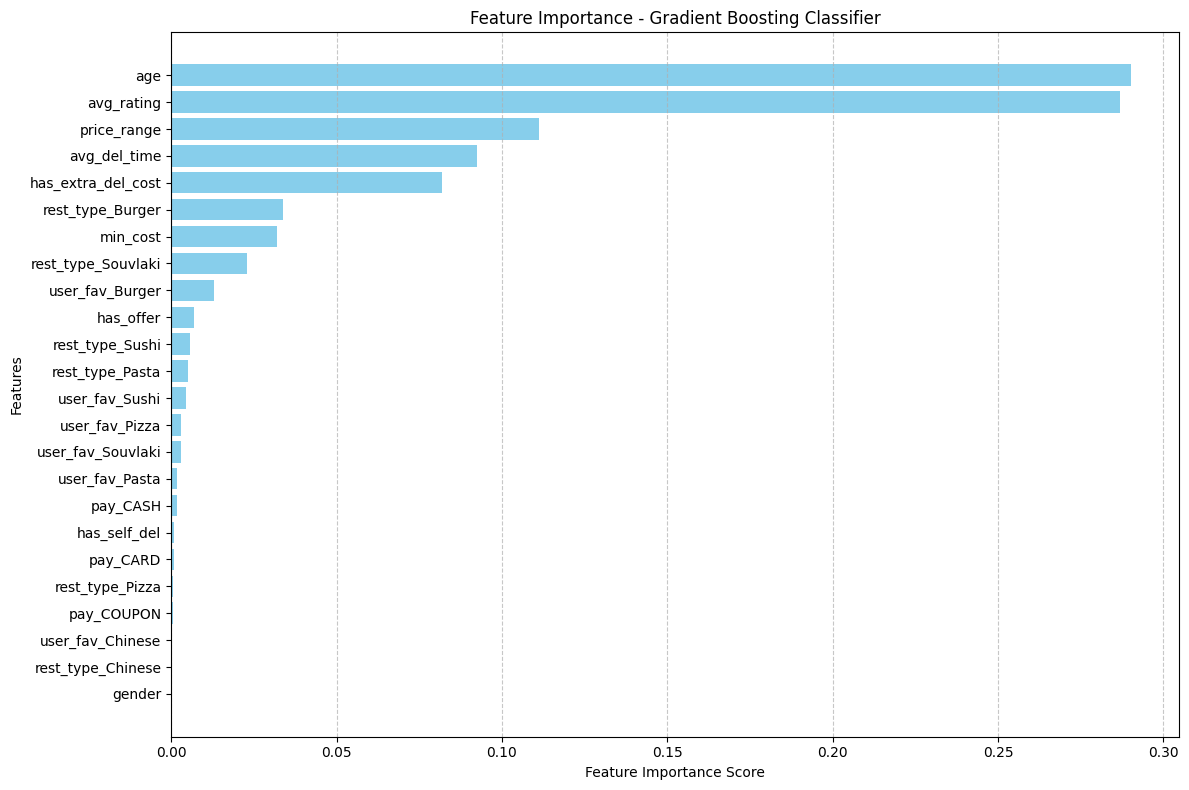

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 1. Make predictions on the test set
y_pred = clf.predict(X_test)

# 2. Calculate and print performance metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score (Weighted): {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 3. Plot Feature Importance
feature_importances = clf.feature_importances_
feature_names = X_train.columns

# Sort features by importance
indices = feature_importances.argsort()[::-1]
sorted_feature_names = [feature_names[i] for i in indices]
sorted_importances = feature_importances[indices]

plt.figure(figsize=(12, 8))
plt.barh(range(len(indices)), sorted_importances, align='center', color='skyblue')
plt.yticks(range(len(indices)), sorted_feature_names)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance - Gradient Boosting Classifier')
plt.gca().invert_yaxis()  # Put most important at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the classifier's performance and provide insights into which features most influence user ratings.


## Summary:

### Q&A

**How did the classifier perform in predicting user preferences?**
The Gradient Boosting classifier achieved an overall accuracy of **80.53\%** and a weighted F1-score of **0.7623**. However, there was a notable performance disparity due to class imbalance: it performed strongly on the majority class (F1-score of 0.89) but struggled significantly with the minority class (F1-score of 0.30, recall of 0.20).

**Which features most influence user ratings?**
The model's decisions were driven by a combination of demographic data, pricing, and restaurant characteristics. The feature importance analysis (visualized via a bar chart) identified specific factors such as `price_range`, cuisine types, and payment methods as the primary drivers of the model's predictions.

### Data Analysis Key Findings

*   **Data Transformation:** Successful conversion of complex list-based columns (`favorite_cuisines`, `payment_methods`) into **15 distinct one-hot encoded features**, and mapping of ordinal data like `price_range` (\$ to 1, \$\$\$\$ to 4).
*   **Dataset Scale:** After preprocessing and feature expansion, the final dataset comprised **154,209 rows and 25 numerical columns**.
*   **Model Training:** A Gradient Boosting Classifier was trained using an 80/20 train-test split, utilizing 100 estimators and a learning rate of 0.1.
*   **Predictive Bottlenecks:** While the accuracy is relatively high at **80.53\%**, the low recall for the minority class indicates the model is conservative in predicting positive ratings (label 1).

### Insights or Next Steps

*   **Address Class Imbalance:** To improve the F1-score for the minority class, future iterations should employ techniques such as SMOTE (Synthetic Minority Over-sampling Technique) or adjust the `class_weight` parameter within the classifier.
*   **Hyperparameter Tuning:** Implement a grid search or random search to optimize the Gradient Boosting parameters (e.g., `max_depth`, `n_estimators`) to boost the model's ability to distinguish between user satisfaction levels.
